In [69]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
import warnings
warnings.filterwarnings('ignore')


In [70]:
df = pd.read_csv('../data/used_cars2.csv')
df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [71]:
def parse_milage(value):
    if pd.isna(value):
        return np.nan
    digits = re.sub(r'[^0-9]', '', str(value))
    return float(digits) if digits else np.nan

def parse_price(value):
    if pd.isna(value):
        return np.nan
    # Handle formats like '$10,900', extra spaces, and other currency symbols.
    cleaned = re.sub(r'[^0-9.]', '', str(value))
    if cleaned.count('.') > 1:
        return np.nan
    return float(cleaned) if cleaned else np.nan

for col in ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']:
    df[col] = df[col].astype(str).str.strip()

df['clean_title'] = df['clean_title'].replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})
df['fuel_type'] = df['fuel_type'].replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})
df['accident'] = df['accident'].replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})

df['milage'] = df['milage'].apply(parse_milage)
df['price'] = df['price'].apply(parse_price)
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')

current_year = pd.Timestamp.now().year
df['car_age'] = (current_year - df['model_year']).clip(lower=0)

for col in ['milage', 'model_year', 'car_age']:
    df[col] = df[col].fillna(df[col].median())

for col in ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']:
    df[col] = df[col].fillna('Unknown').astype(str)

df = df.dropna(subset=['price']).copy()
df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0,4
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0,5


In [72]:
# check Missing value
df.isnull().sum()


brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
car_age         0
dtype: int64

In [73]:
# Check Duplication
df.duplicated().sum()


np.int64(0)

In [74]:
df.dtypes


brand               str
model               str
model_year        int64
milage          float64
fuel_type           str
engine              str
transmission        str
ext_col             str
int_col             str
accident            str
clean_title         str
price           float64
car_age           int64
dtype: object

In [75]:
df.nunique()


brand             57
model           1898
model_year        34
milage          2818
fuel_type          8
engine          1146
transmission      62
ext_col          319
int_col          156
accident           3
clean_title        2
price           1569
car_age           34
dtype: int64

In [76]:
df.describe()


,model_year,milage,price,car_age
count,4009.000000,4009.000000,4.009000e+03,4009.000000
mean,2015.515590,64717.551010,4.455319e+04,10.484410
std,6.104816,52296.599459,7.871064e+04,6.104816
min,1974.000000,100.000000,2.000000e+03,2.000000
25%,2012.000000,23044.000000,1.720000e+04,6.000000
50%,2017.000000,52775.000000,3.100000e+04,9.000000
75%,2020.000000,94100.000000,4.999000e+04,14.000000
max,2024.000000,405000.000000,2.954083e+06,52.000000


In [77]:
categorical_columns = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
                       'ext_col', 'int_col', 'accident', 'clean_title']

for col in categorical_columns:
    print(f'Category in {col} is : {df[col].nunique()} unique values')


Category in brand is : 57 unique values
Category in model is : 1898 unique values
Category in fuel_type is : 8 unique values
Category in engine is : 1146 unique values
Category in transmission is : 62 unique values
Category in ext_col is : 319 unique values
Category in int_col is : 156 unique values
Category in accident is : 3 unique values
Category in clean_title is : 2 unique values


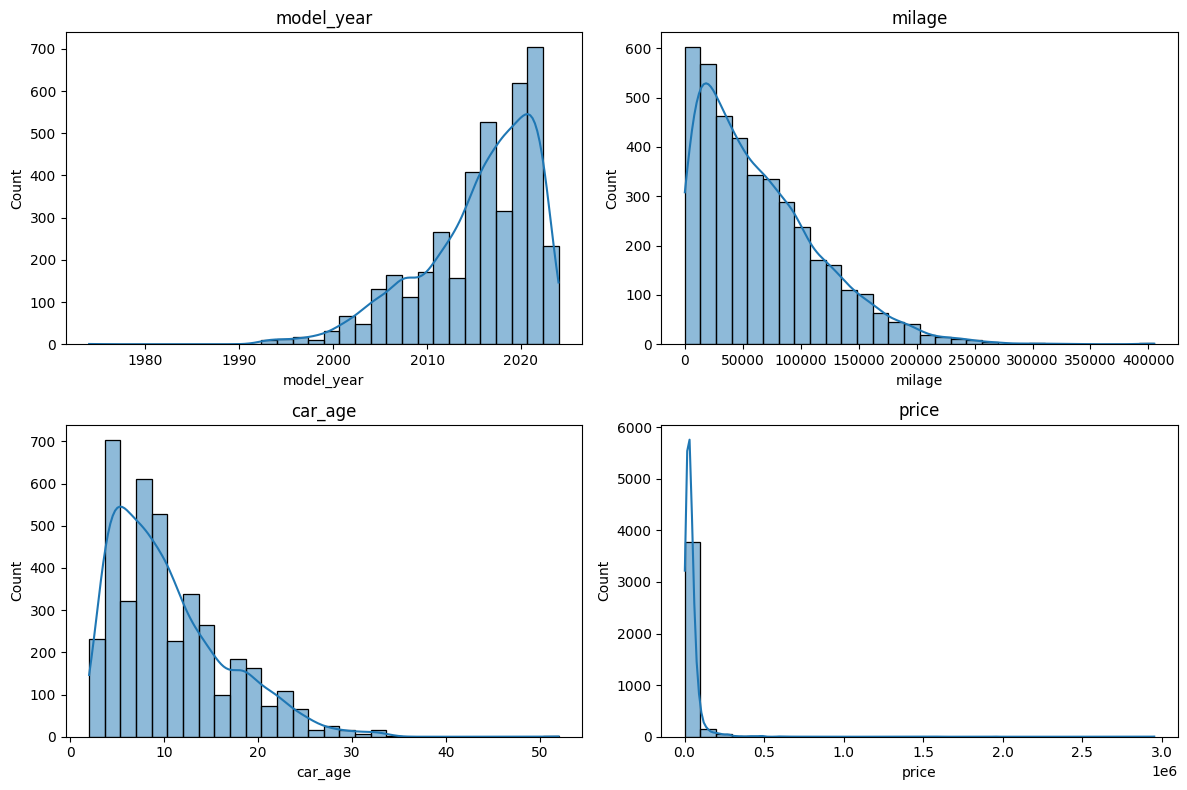

In [78]:
# Distribution of Numerical Features
# Create a visualization-friendly view to reduce outlier compression on charts.
viz_df = df.copy()
price_cap = viz_df['price'].quantile(0.99)
viz_df['price_capped'] = viz_df['price'].clip(upper=price_cap)
viz_df['price_log1p'] = np.log1p(viz_df['price'])

numerical_features = ['model_year', 'milage', 'car_age', 'price_capped']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, start=1):
    plt.subplot(2, 2, i)
    sns.histplot(data=viz_df[feature], bins=30, kde=True)
    title = feature if feature != 'price_capped' else 'price (capped at q99)'
    plt.title(title)
plt.tight_layout()
plt.show()


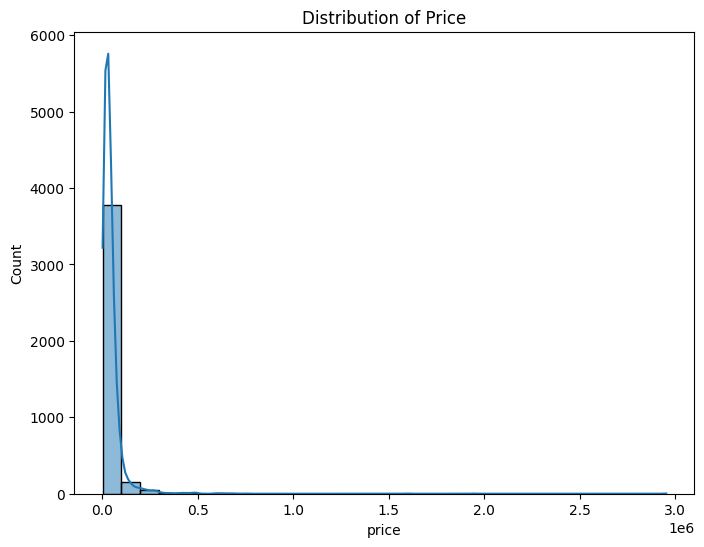

In [79]:
# Price Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=viz_df['price_capped'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price (capped at q99)')
axes[0].set_xlabel('price')

sns.histplot(data=viz_df['price_log1p'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of log1p(Price)')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()
plt.show()


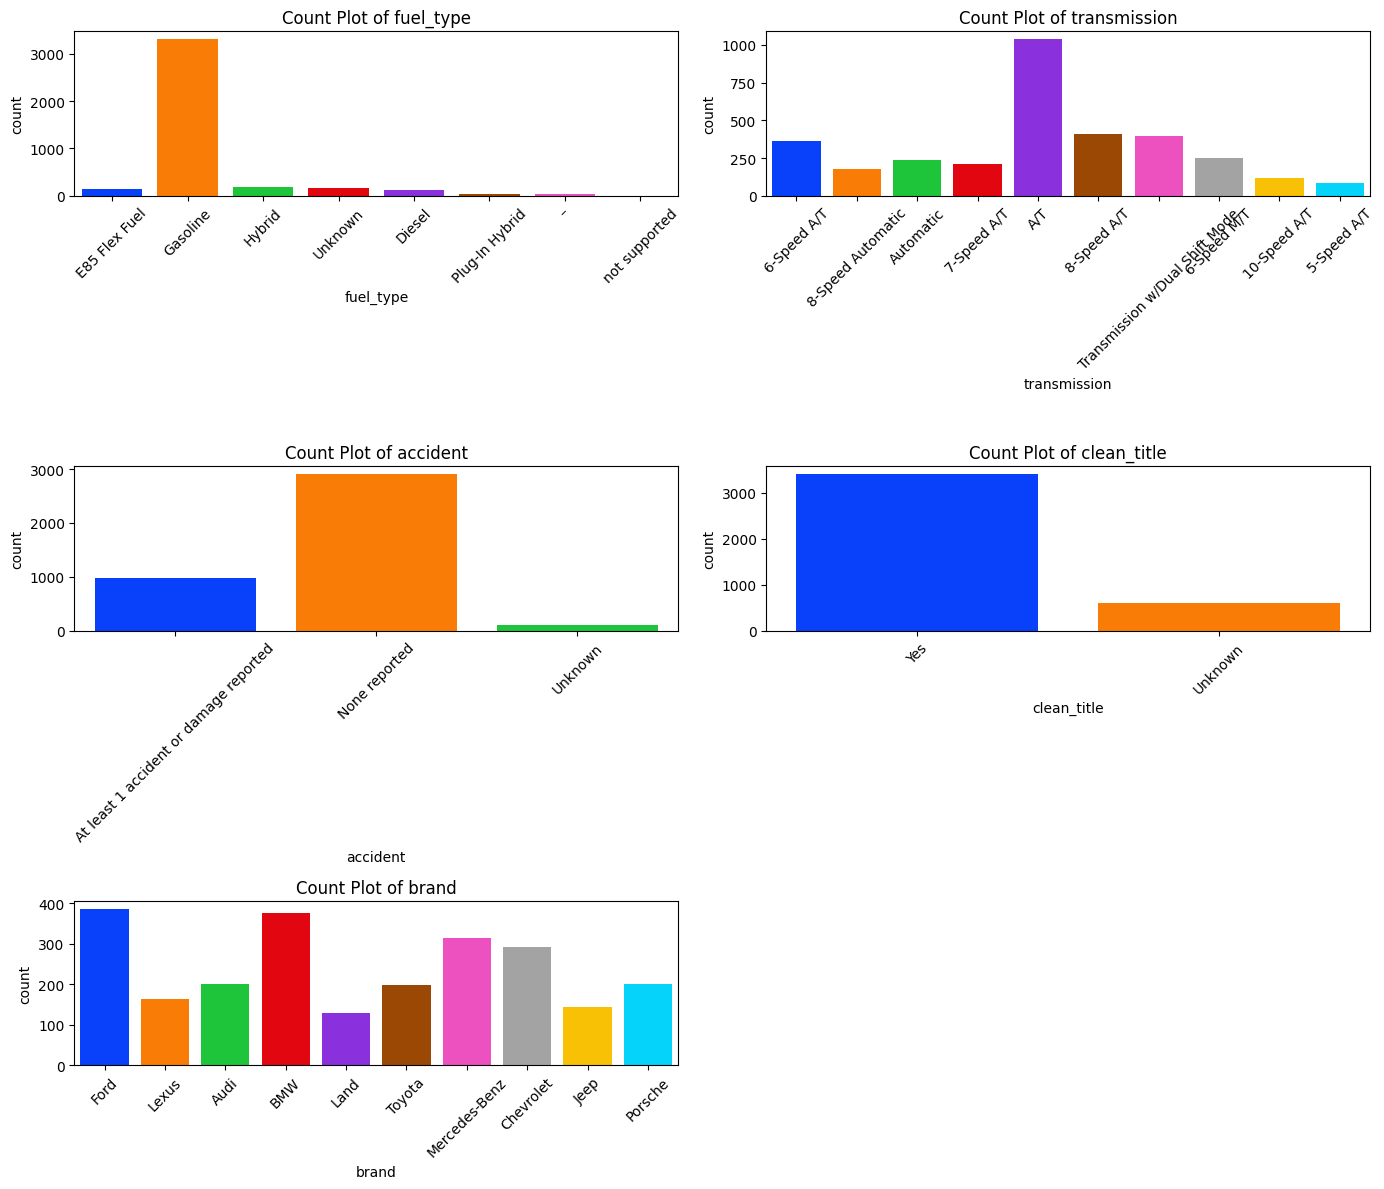

In [80]:
# Define the list of categorical columns to analyze
plot_cats = ['fuel_type', 'transmission', 'accident', 'clean_title', 'brand']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.ravel()

for i, column in enumerate(plot_cats):
    # Keep only top categories to improve readability.
    cleaned = df[column].astype(str).str.strip()
    cleaned = cleaned.replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown', '-': 'Unknown'})
    top_vals = cleaned.value_counts().head(10).index
    sub = cleaned[cleaned.isin(top_vals)]

    sns.countplot(x=sub, palette='bright', ax=axes[i], saturation=0.95)
    axes[i].set_title(f'Count Plot of {column} (top 10)')
    axes[i].set_xlabel(column)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(plot_cats), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


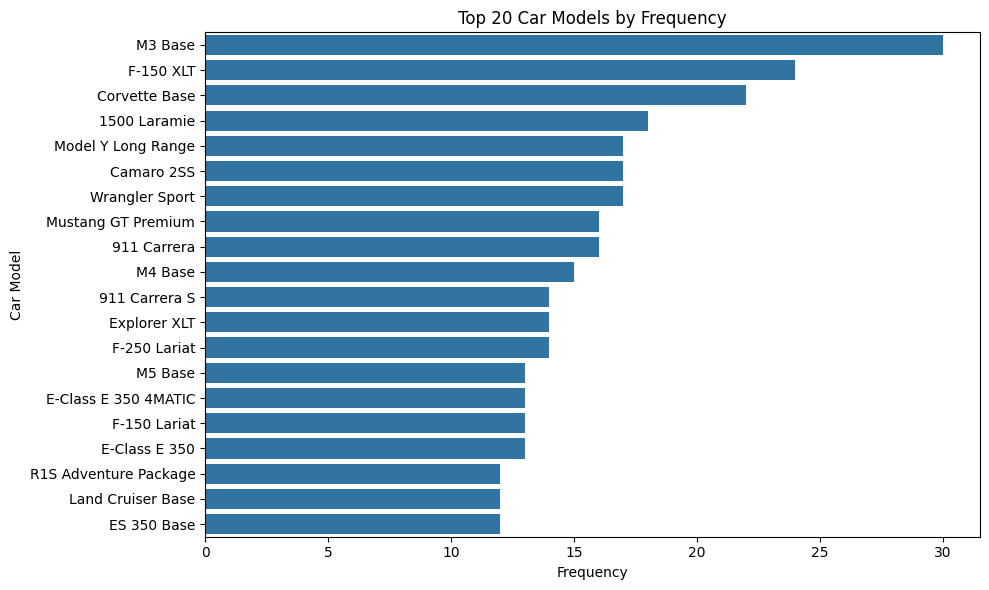

In [ ]:
n = 20
top_car_models = df['model'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Models by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()


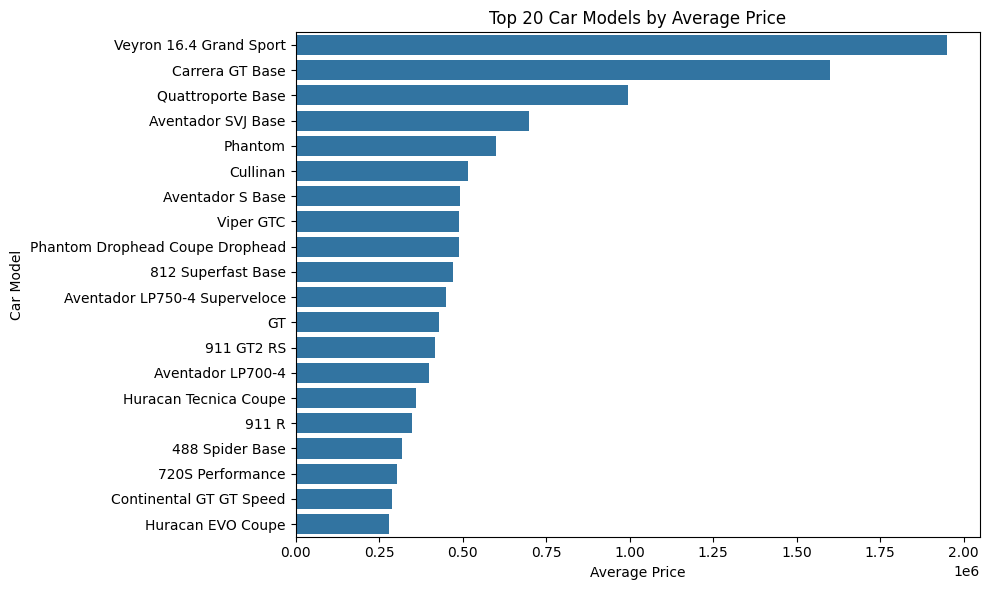

In [82]:
# Calculate average price for each car model
avg_prices_by_car = df.groupby('model')['price'].mean().sort_values(ascending=False)

# Plot top N car models by average price
n = 20
top_car_models = avg_prices_by_car.head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()


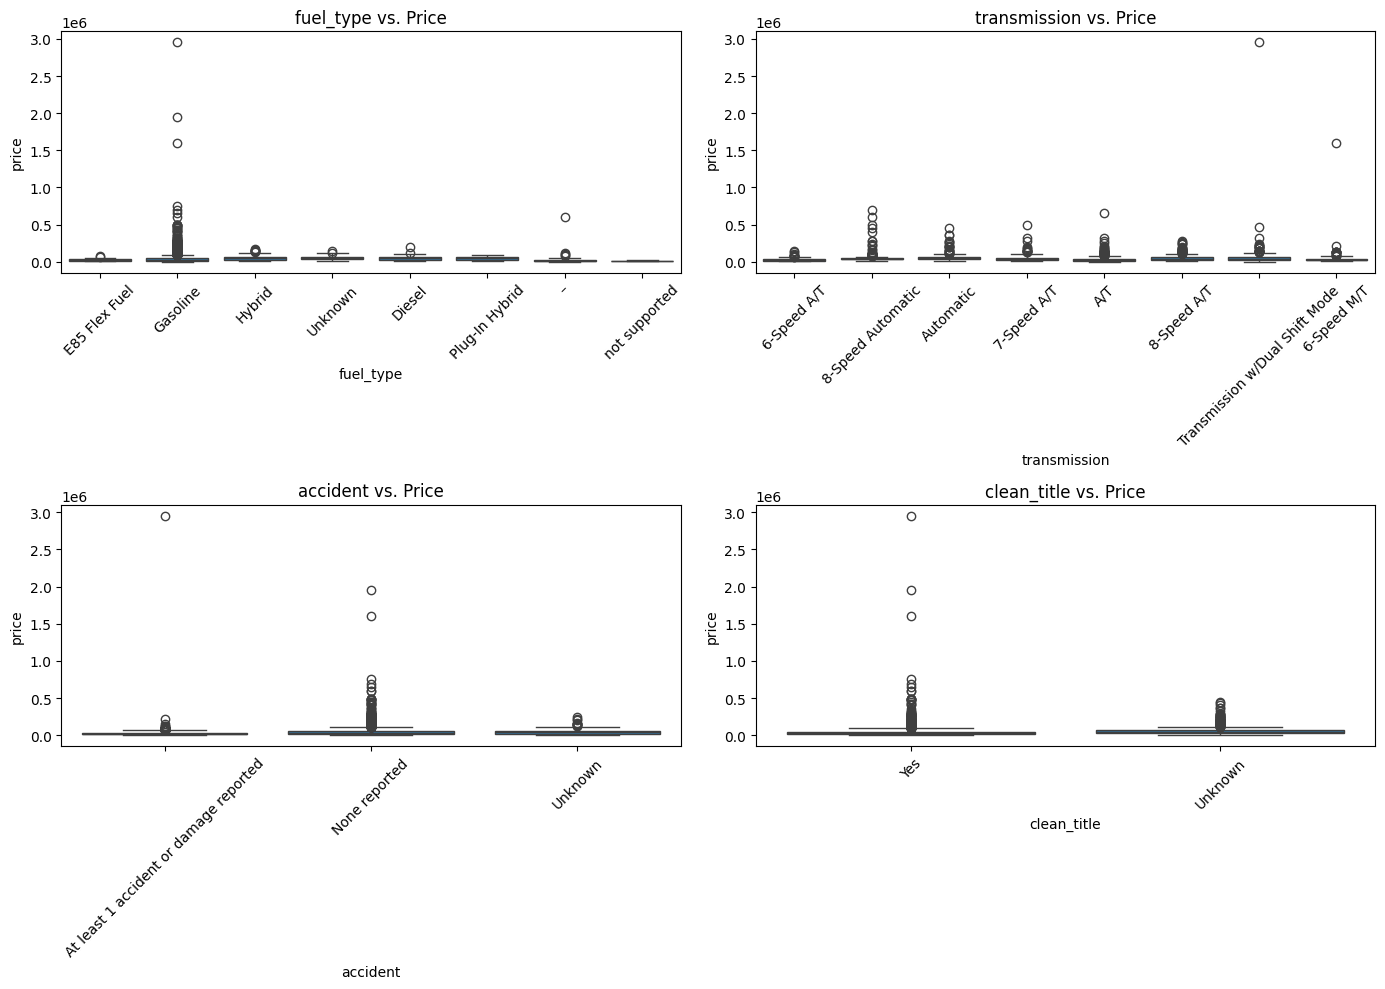

In [83]:
# Categorical Feature vs. Price
plt.figure(figsize=(14, 10))
for i, feature in enumerate(['fuel_type', 'transmission', 'accident', 'clean_title'], start=1):
    plt.subplot(2, 2, i)

    feature_clean = df[feature].astype(str).str.strip().replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown', '-': 'Unknown'})
    top_vals = feature_clean.value_counts().head(8).index
    mask = feature_clean.isin(top_vals)

    sub = pd.DataFrame({
        feature: feature_clean[mask],
        'price_log1p': np.log1p(df.loc[mask, 'price'])
    })

    sns.boxplot(data=sub, x=feature, y='price_log1p', showfliers=False)
    plt.title(f'{feature} vs. log1p(Price)')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


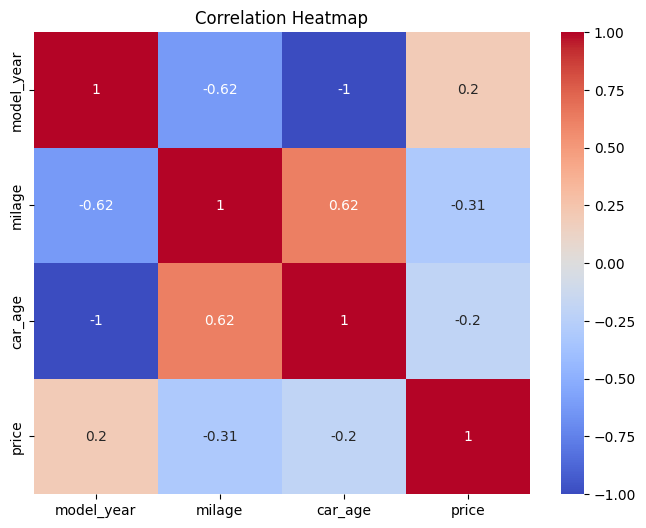

In [84]:
# Correlation Analysis
# Use a dedicated numeric list from df to avoid dependency on viz-only columns.
correlation_features = ['model_year', 'milage', 'car_age', 'price']
correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [85]:
brand_model_map = df.groupby('brand')['model'].apply(lambda x: sorted(list(x.astype(str).unique()))).to_dict()

unique_brands = sorted(df['brand'].astype(str).unique().tolist())
print(f'Створено карту Бренд -> Модель для {len(unique_brands)} брендів.')

categorical_columns = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
                       'ext_col', 'int_col', 'accident', 'clean_title']
numerical_columns = ['model_year', 'milage', 'car_age']


Створено карту Бренд -> Модель для 57 брендів.


In [86]:
label_encoders_dict = {}
for column in categorical_columns:
    le = LabelEncoder()
    df[column] = df[column].astype(str)
    le.fit(df[column])
    label_encoders_dict[column] = le
    df[column] = le.transform(df[column])

print('Категоріальні колонки закодовано LabelEncoder.')


Категоріальні колонки закодовано LabelEncoder.


In [87]:
# Feature engineering
df['milage_per_year'] = df['milage'] / (df['car_age'] + 1)
for column in numerical_columns:
    df[f'{column}_squared'] = df[column] ** 2

df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in numerical_columns + ['milage_per_year']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())


In [88]:
# Feature scaling
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

X = df.drop(['price'], axis=1)
y = df['price']

feature_columns_list = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Дані підготовлено для навчання. Кількість фіч: {len(feature_columns_list)}')


Дані підготовлено для навчання. Кількість фіч: 16


In [89]:
# --- 3. Тренування моделі Lasso ---
print('\n--- 3. Тренування моделі Lasso ---')

model = Lasso(alpha=100.0, random_state=42, max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2_square = r2_score(y_test, y_pred)
print(f'R-squared (Lasso, alpha=100.0): {r2_square:.4f}')
print(f'Mean Squared Error (Lasso, alpha=100.0): {mse:.2f}')



--- 3. Тренування моделі Lasso ---
R-squared (Lasso, alpha=100.0): 0.0633
Mean Squared Error (Lasso, alpha=100.0): 19144823165.49


In [90]:
print(f'\nLasso (alpha=100.0) залишив {np.sum(model.coef_ != 0)} з {len(model.coef_)} фіч:')
for feature, coef in zip(feature_columns_list, model.coef_):
    if coef != 0:
        print(f'  [ЗАЛИШЕНО] {feature}: {coef:.2f}')



Lasso (alpha=100.0) залишив 14 з 16 фіч:
  [ЗАЛИШЕНО] brand: 247.62
  [ЗАЛИШЕНО] model: -4.51
  [ЗАЛИШЕНО] milage: -13324.56
  [ЗАЛИШЕНО] fuel_type: -6113.68
  [ЗАЛИШЕНО] engine: 54.22
  [ЗАЛИШЕНО] transmission: 93.32
  [ЗАЛИШЕНО] ext_col: 7.65
  [ЗАЛИШЕНО] int_col: 58.41
  [ЗАЛИШЕНО] accident: 3173.85
  [ЗАЛИШЕНО] clean_title: -250.96
  [ЗАЛИШЕНО] milage_per_year: -4.14
  [ЗАЛИШЕНО] model_year_squared: 1.02
  [ЗАЛИШЕНО] milage_squared: 0.00
  [ЗАЛИШЕНО] car_age_squared: 68.98


In [91]:
saved_objects = {
    "model": model,
    "scaler": scaler,
    "label_encoders": label_encoders_dict,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "feature_columns": feature_columns_list,
    "unique_brands": unique_brands,
    "brand_model_map": brand_model_map
}

save_dir = "models"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Створено директорію {save_dir}")

save_path = os.path.join(save_dir, "car_price_model.pkl")
with open(save_path, "wb") as f:
    pickle.dump(saved_objects, f)

print(f"\nУСПІХ! Модель Lasso та всі артефакти збережено у {save_path}!")



УСПІХ! Модель Lasso та всі артефакти збережено у models\car_price_model.pkl!
